In [32]:
"""
SHARED FIGURE STYLE -- run this cell first
=========================================
Colours, panel sizes, type and saving all come from paper-individuality/paper_style.py,
so this notebook's figures match every other figure in the paper and the poster.
Nothing below hardcodes a hex colour or a point size; switching mode re-renders the
whole notebook:

    ps.use('poster')   big type, big panels -- what a poster needs
    ps.use('paper')    journal column widths, 7 pt type

`session_filters` sits next to this notebook, so its folder goes on the path too --
that way the notebook also runs from a different working directory.
"""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'learning_individuality')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps

ps.use('poster')      # 'poster' = big type for a poster; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

In [33]:
""" 
IMPORTS
"""
import os
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# --Machine learning and statistics
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import zscore

In [34]:
""" IMPORTANT PATHS """
# The data lives in a different place on each machine, so the path is resolved rather
# than hardcoded: the first candidate that actually exists wins. A wrong base_path
# used to surface much later as "no usable timepoint left" in the parameters cell,
# because every syllable file looked missing.
BASE_CANDIDATES = [
    '/home/ines/repositories/representation_learning_variability/paper-individuality/data/',
    os.path.expanduser('~/Documents/Repositories/representation_learning_variability/'
                       'paper-individuality/data/'),
    ('/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/'
     'paper-individuality/data/newly_generated/segmentation/'),
]
base_path = next((b for b in BASE_CANDIDATES if os.path.isdir(b)), None)
assert base_path is not None, ("none of these exist:\n  " + "\n  ".join(BASE_CANDIDATES))
print('base_path:', base_path)


base_path: /home/ines/repositories/representation_learning_variability/paper-individuality/data/


In [35]:
def filter_sequences(all_sequences):
    print(str(len(all_sequences.mouse_name.unique())) + str(' mice in total'))
    print(str(len(all_sequences.session.unique())) + str(' sessions in total'))

    # FIX: Use drop=True to avoid creating 'index' column
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    print(str(len(all_sequences['session'].unique())) + str(' sessions after removing bad sessions'))

    # Filter out mice without enough sessions
    session_count = all_sequences[['mouse_name', 'session']].drop_duplicates().groupby(['mouse_name'])['session'].count().reset_index()
    multi_sess_mice = session_count.loc[session_count['session']>2, 'mouse_name']

    # FIX: Use drop=True here too
    all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
    print(str(len(multi_sess_mice)) + str(' mice with at least 3 sessions'))
    print(str(len(all_sequences['session'].unique())) + str(' remaining sessions'))

    # Validation
    assert 'index' not in all_sequences.columns, "ERROR: 'index' column created by reset_index!"
    print("✓ Data preparation validated")
    return all_sequences

In [36]:
def binarize(use_sequences, n_paw_states=8, 
             keep_paw=True, keep_whisk=True, keep_lick=True):
    """
    Binarizes behavioral sequence data dynamically based on the number of paw states.
    Automatically infers feature dimensions based on the requested combination.
    
    Parameters:
    -----------
    use_sequences : np.ndarray
        Array of shape (n_trials, timesteps) containing encoded integer states or NaNs.
    n_paw_states : int
        The number of possible paw states (defaults to 8).
    keep_paw : bool
        Whether to keep the binarized paw states (automatically drops reference state 1).
    keep_whisk : bool
        Whether to keep the whisking state.
    keep_lick : bool
        Whether to keep the licking state.
        
    Returns:
    --------
    binarized_reduced : np.ndarray
        The filtered sequence array.
    n_out_features : int
        The number of features per timestep in the final output array.
    """
    if not (keep_paw or keep_whisk or keep_lick):
        raise ValueError("At least one feature type (paw, whisk, or lick) must be kept.")

    # The raw decoding always requires n_paw_states + 1 (whisk) + 1 (lick) columns
    n_raw_features_per_step = n_paw_states + 2 

    n_trials = use_sequences.shape[0]
    timesteps = use_sequences.shape[1]

    binarized = np.zeros((n_trials, timesteps * n_raw_features_per_step))
    
    for t in range(timesteps):
        current_vals = use_sequences[:, t]
        nan_mask = np.isnan(current_vals)
        valid_mask = ~nan_mask
        labels_0idx = current_vals[valid_mask].astype(int)
        
        start_col = t * n_raw_features_per_step
        
        if len(labels_0idx) > 0:  
            valid_row_idx = np.arange(n_trials)[valid_mask]
            
            # 1. Fill Paw States (Cols 0 to n_paw_states-1)
            paw_indices = labels_0idx % n_paw_states
            binarized[valid_row_idx, start_col + paw_indices] = 1
            
            # 2. Fill Whisking (Col equal to n_paw_states)
            whisking_col = start_col + n_paw_states
            binarized[valid_mask, whisking_col] = ((labels_0idx // n_paw_states) % 2).astype(int)
            
            # 3. Fill Licking (Col equal to n_paw_states + 1)
            licking_col = start_col + n_paw_states + 1
            binarized[valid_mask, licking_col] = (labels_0idx // (n_paw_states * 2)).astype(int)
        
        # Set all features for this timestep to NaN where original data was NaN
        if np.any(nan_mask):
            feature_cols = slice(start_col, start_col + n_raw_features_per_step)
            binarized[nan_mask, feature_cols] = np.nan

    # Determine which columns to keep within a single timestep block
    cols_to_keep_base = []
    if keep_paw:
        # Keep all paw states EXCEPT index 1 (Paw State 2)
        cols_to_keep_base.extend([i for i in range(n_paw_states) if i != 1])
    if keep_whisk:
        cols_to_keep_base.append(n_paw_states)
    if keep_lick:
        cols_to_keep_base.append(n_paw_states + 1)

    n_out_features = len(cols_to_keep_base)

    # Expand these base indices across all timesteps
    all_cols_to_keep = []
    for t in range(timesteps):
        offset = t * n_raw_features_per_step
        all_cols_to_keep.extend([offset + c for c in cols_to_keep_base])
        
    # Slice the array to keep only the requested features
    binarized_reduced = binarized[:, all_cols_to_keep]
    
    return binarized_reduced

In [37]:
def build_design_matrix(train_file, test_file, exclude_sessions):
    
    # Load training set as proficient data
    train_sequences = pd.read_parquet(train_file)
    train_sequences['session'] = train_sequences['sample'].str[:36]
    train_sequences = filter_sequences(train_sequences)
    train_sequences['fold'] = 'train'

    # Load test set to append
    test_sequences = pd.read_parquet(test_file)
    test_sequences['session'] = test_sequences['sample'].str[:36]
    test_sequences['fold'] = 'test'
    test_sequences = test_sequences.loc[~test_sequences['session'].isin(exclude_sessions)]

    # Merge
    all_sequences = pd.concat([train_sequences, test_sequences])

    # if 'syllables' in filename or 'sequences' in filename:     
    design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type', 'fold'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
    # Remove any spurious 'index' column created by reset_index
    if 'index' in design_df.columns:
        design_df = design_df.drop(columns=['index'])
    design_df = design_df.sort_values(by='session')

    # Validate
    assert len(design_df) > 0, "ERROR: design_df is empty after filtering!"
    print(f"✓ design_df created: {len(design_df)} rows, {design_df['mouse_name'].nunique()} mice, {design_df['session'].nunique()} sessions")

    epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
    use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

    # Validate alignment
    assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length ({len(use_sequences)}) != design_df length ({len(design_df)})"

    # --- PARAMETERS ---
    use_format = binarize(use_sequences, n_paw_states=8, 
                keep_paw=True, keep_whisk=True, keep_lick=True)

    # Average per session (per data type)
    session_mouse_mapping = design_df[['session', 'mouse_name']].drop_duplicates()
    session_mouse_mapping = session_mouse_mapping.set_index('session')['mouse_name'].to_dict()
    session_fold_mapping = design_df[['session', 'fold']].drop_duplicates()
    session_fold_mapping = session_fold_mapping.set_index('session')['fold'].to_dict()

    # Validate: each session maps to exactly one mouse
    assert len(session_mouse_mapping) == len(design_df[['session', 'mouse_name']].drop_duplicates()), \
        "ERROR: A session maps to multiple mice!"

    session_syllables = pd.DataFrame(use_format)
    session_syllables['session'] = design_df['session'].values
    session_syllables = session_syllables.groupby('session', sort=False)[np.arange(0, np.shape(use_format)[1], 1)].mean()

    # Create mouse name labels using explicit mapping
    mouse_names_list = np.array([session_mouse_mapping[sess] for sess in session_syllables.index])
    folds_list = np.array([session_fold_mapping[sess] for sess in session_syllables.index])

    print(f"✓ Session aggregation complete: {len(session_syllables)} sessions")
    print(f"✓ Mouse labels: {dict(zip(*np.unique(mouse_names_list, return_counts=True)))}")
    
    # design_df = session_syllables.drop_duplicates()
    design_df = design_df[['mouse_name', 'session', 'fold']].drop_duplicates()
    print(f"✓ Combined design matrix: {len(session_syllables)} sessions, {session_syllables.shape[1]} features ")

    # plt.figure(figsize=(10, 4))
    # plt.imshow(np.array(session_syllables), aspect='auto', cmap='viridis', interpolation='none')
    # plt.xticks(np.arange(0, session_syllables.shape[1], 160), np.arange(0, session_syllables.shape[1], 160))
    # plt.xlabel('Syllables')
    # plt.ylabel('Sessions')
    # plt.show()

    return session_syllables, design_df, mouse_names_list, folds_list

In [38]:
def restrict_to_mice(built_entry, keep_mice):
    """
    Keep only the sessions belonging to `keep_mice`, in every row-aligned object that
    build_design_matrix returned (session_syllables / design_df / mouse_names / folds).

    keep_mice=None returns everything untouched, i.e. the original behaviour where each
    timepoint is scored on whatever mice happen to have a session at that timepoint.
    """
    session_syllables = built_entry['session_syllables']
    design_df         = built_entry['design_df']
    mouse_names_list  = built_entry['mouse_names']
    folds_list        = built_entry['folds']

    if keep_mice is None:
        return session_syllables, design_df, mouse_names_list, folds_list

    keep_mice = list(keep_mice)
    keep = np.isin(mouse_names_list, keep_mice)
    assert keep.sum() > 0, "no session left after restricting to the common cohort"

    session_syllables = session_syllables.iloc[keep]
    mouse_names_list  = mouse_names_list[keep]
    folds_list        = folds_list[keep]
    design_df         = design_df.loc[design_df['mouse_name'].isin(keep_mice)]

    # Both folds must survive, otherwise the LDA has nothing to fit or nothing to score
    assert np.any(folds_list == 'train'), "cohort has no proficient (train) session"
    assert np.any(folds_list == 'test'),  "cohort has no session at this timepoint"
    return session_syllables, design_df, mouse_names_list, folds_list

In [39]:
def dim_red(session_syllables, folds_list, n_component):
    """
    PCA + z-scoring, FIT ON THE TRAINING (proficient) SESSIONS ONLY and then applied
    to every session. Previously both were fit on all sessions at once, so the
    held-out timepoint sessions helped define the components they were later
    classified in -- which inflated every accuracy in the sweep.
    """
    all_features = session_syllables.copy()

    train_index = np.where(folds_list=='train')[0]
    test_index = np.where(folds_list=='test')[0]

    train_set = np.array(all_features.iloc[train_index])

    # PCA -- as many components as the TRAINING set supports
    n_components = np.min([np.shape(train_set)[0], np.shape(train_set)[1]])
    # Step 1: fit the reduction on the training sessions...
    pca = PCA(n_components)
    pca.fit(train_set)
    # ...then project ALL sessions (train and test) through it
    X_pca = pca.transform(np.array(all_features))

    # Explained variance ratio (of the training sessions)
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    threshold = 0.6
    min_components = np.where(cumulative_variance>threshold)[0][0]
    # min_components = 20
    print(str(min_components) + ' components explain ' + str(threshold) +' of total variance')

    # # Plot explained variance
    # plt.figure(figsize=(8, 5))
    # plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
    # plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
    # plt.hlines(threshold, 0, 250, 'black', 'dashed')
    # plt.vlines(min_components, 0, 1, 'black', 'dashed')
    # plt.xlabel("Number of Principal Components")
    # plt.ylabel("Variance Explained")
    # plt.title("Explained Variance by PCA")
    # plt.show()

    # mat = np.array(session_syllables.copy())
    mat = np.array(X_pca[:, :n_component])

    # Same rule for the scaler: mean/scale come from the training sessions only
    scaler = StandardScaler()
    scaler.fit(mat[train_index])
    norm_pop = scaler.transform(mat)

    return norm_pop, min_components

In [40]:
def lda_analysis(norm_pop, mouse_names_list, folds_list, min_components, n_per_mouse=4,
                 n_repeats=100, lda_to_check=0, n_perm=200):
    """
    n_repeats : how many balanced training subsamples to average the accuracy over.
    n_perm    : how many shuffled-label fits form the null distribution. This is
                DECOUPLED from n_repeats on purpose: a permutation p-value cannot
                go below 1/(n_perm+1), so tying it to a small n_repeats made the
                test incapable of ever reaching p < 0.05.
    """

    # --- Fix for row-alignment using previously defined lists ---
    y = pd.factorize(mouse_names_list)[0]

    # Create perfectly aligned indices
    test_mice = np.unique(mouse_names_list[folds_list == 'test'])
    is_test_mouse = np.isin(mouse_names_list, test_mice)
    is_train_fold = folds_list == 'train'
    is_test_fold  = folds_list == 'test'

    train_index = np.where(is_test_mouse & is_train_fold)[0]
    test_index  = np.where(is_test_mouse & is_test_fold)[0]

    # train_index = np.where(is_train_fold)[0]
    # test_index  = np.where(is_test_fold)[0]

    X_train_full = np.array(norm_pop)[train_index, :]
    y_train_full = y[train_index]

    # X_train_full = np.array(norm_pop)
    # y_train_full = y

    X_test_all = np.array(norm_pop)[test_index, :]
    y_test_all = y[test_index]

    n_samples = len(test_index)

    # Number of mice the classifier can actually choose between: mice that survive the
    # balanced-subsampling filter below (>= n_per_mouse-1 training sessions).
    # Chance level for this dataset is 1 / n_classes.
    _, train_counts = np.unique(y_train_full, return_counts=True)
    # every mouse with at least one training session is a class the LDA can choose, now
    # that the cap no longer excludes the sparse ones. Chance is 1 / n_classes, so this
    # has to be the set the classifier actually fits or the chance level is wrong.
    n_classes = int(np.sum(train_counts >= 1))

    # Discriminants are bounded by the number of classes the LDA actually fits,
    # not by the total number of mice in the design matrix.
    lda_components = np.min([min_components, n_classes - 1])

    # --- IS THIS POINT EVEN ESTIMABLE? ---
    # solver='eigen' solves eigh(Sb, Sw), which REQUIRES Sw positive definite. The balanced
    # subsample gives each mouse n_per_mouse-1 sessions, so the within-class scatter has
    #     dof = n_classes * (n_per_mouse - 2)
    # degrees of freedom, and Sw is singular as soon as n_features exceeds that. Ledoit-Wolf
    # ('auto') shrinkage does not rescue it: with 2 sessions per mouse each class covariance
    # is rank 1.
    #
    # Measured on this dataset (37 mice): n_per_mouse=3 -> dof 37, so 30 PCA dims fit and 40
    # raise `LinAlgError: leading minor of order 39 of B is not positive definite`;
    # n_per_mouse=4 -> dof 74, and the whole grid up to 60 runs.
    #
    # Those points are skipped rather than regularised into existence: a Sw estimated from
    # one degree of freedom per mouse would yield discriminants that are mostly noise, so a
    # number there would look real without being real.
    n_features = np.shape(norm_pop)[1]
    # exact, not n_classes * (n_per_mouse - 2): with the corrected cap a mouse contributes
    # min(cap, its sessions), so sparse mice add fewer than cap-1 degrees of freedom
    within_dof = int(np.sum(np.maximum(np.minimum(train_counts, n_per_mouse) - 1, 0)))
    if n_features > within_dof:
        print(f"  SKIPPED: {n_features} features but only {within_dof} within-class dof "
              f"across {n_classes} mice. Raise n_per_mouse, or keep "
              f"n_components <= {within_dof}.")
        _nan = np.array([np.nan])
        return dict(true_scores=_nan, shuffle_scores=_nan, n_classes=n_classes,
                    ci_low=np.nan, ci_high=np.nan, p_perm=np.nan, p_floor=np.nan,
                    per_session_hit=np.full(n_samples, np.nan),
                    prof_score=np.nan, prof_ci_low=np.nan, prof_ci_high=np.nan,
                    prof_n_mice=0)

    # Store repeat accuracy results
    true_scores_all = []
    shuffle_scores_all = []
    # HELD-OUT PROFICIENT SESSIONS. The balanced subsample trains on n_per_mouse-1
    # proficient sessions per mouse; the rest were simply unused. Scoring them with
    # the same LDA gives the reference this sweep was missing: how identifiable a
    # mouse is from its own proficient behaviour, with no timepoint change involved.
    # Only mice with MORE than n_per_mouse-1 proficient sessions can contribute.
    prof_scores_all = []
    prof_hit = {}
    # Per-test-session hit/miss, kept so the error bars can resample MICE (the test
    # set is identical across repeats, so the spread across repeats only describes
    # sensitivity to the training subsample -- not uncertainty in the accuracy)
    correct_per_session = np.zeros((n_repeats, n_samples))

    # --- Variables for LDA Transform Tracking ---
    # Matrices to store the transformed values for each test sample across all repeats
    ld_train_means_all = np.zeros((n_repeats, n_samples))
    ld_test_vals_all = np.zeros((n_repeats, n_samples))

    for repeat in range(n_repeats):
        # Seeded so the sweep is reproducible run to run
        rng = np.random.default_rng(repeat)

        # --- balanced subsampling for training ---
        # THE CAP IS A MAXIMUM CONTRIBUTION, NOT A MINIMUM REQUIREMENT.
        # The old rule (`if len(m_idx) >= n_per_mouse-1`) dropped a mouse with fewer
        # sessions than the cap out of TRAINING while its sessions stayed in the TEST set
        # -- guaranteed misses against a classifier that had never seen that class. Worse
        # here than elsewhere: n_classes excluded those mice from the chance level, so they
        # were scored as errors against a chance level that pretended they did not exist.
        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            # cap = n_per_mouse itself. The -1 dated from the broken guard, where 2 was
            # the largest cap every mouse could always meet; take = min(...) handles short
            # mice directly. Matches LDA_analyses_pipeline_ALLSESSIONS and functions.run_lda.
            take = min(n_per_mouse, len(m_idx))
            if take > 0:
                balanced_idx.extend(rng.choice(m_idx, take, replace=False))
                
        balanced_idx = np.array(balanced_idx)
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        priors = np.ones(len(np.unique(y_train))) / len(np.unique(y_train))

        # --- true labels run ---
        lda = LinearDiscriminantAnalysis(
            solver='eigen', shrinkage='auto',
            priors=priors, n_components=lda_components)
        lda.fit(X_train, y_train)
        true_pred = lda.predict(X_test_all)
        correct_per_session[repeat, :] = (true_pred == y_test_all)
        true_scores_all.append(np.mean(true_pred == y_test_all))

        # --- the same LDA on the proficient sessions it did NOT train on ---
        held = np.setdiff1d(np.arange(len(y_train_full)), balanced_idx)
        held = held[np.isin(y_train_full[held], np.unique(y_train))]
        if len(held):
            ok = lda.predict(X_train_full[held]) == y_train_full[held]
            prof_scores_all.append(float(np.mean(ok)))
            for cls, hit in zip(y_train_full[held], ok):
                c = prof_hit.setdefault(int(cls), [0, 0])
                c[0] += int(hit); c[1] += 1

        # --- Calculate and store projections (your added logic) ---
        transformed_train = lda.transform(X_train)
        transformed_test = lda.transform(X_test_all)

        for i_idx, true_class in enumerate(y_test_all):
            # 1. Mean projection of this class in the training set
            train_mean_val = np.mean(transformed_train[y_train == true_class, lda_to_check])
            # 2. Projection of this specific held-out test sample
            test_val = transformed_test[i_idx, lda_to_check]
            
            ld_train_means_all[repeat, i_idx] = train_mean_val
            ld_test_vals_all[repeat, i_idx] = test_val

    # --- null distribution: n_perm shuffled-label fits ---
    # Each draw gets its own balanced subsample AND its own label permutation, so
    # the null marginalises over both, exactly like the true score does.
    for perm in range(n_perm):
        rng = np.random.default_rng(10_000 + perm)

        # THE CAP IS A MAXIMUM CONTRIBUTION, NOT A MINIMUM REQUIREMENT.
        # The old rule (`if len(m_idx) >= n_per_mouse-1`) dropped a mouse with fewer
        # sessions than the cap out of TRAINING while its sessions stayed in the TEST set
        # -- guaranteed misses against a classifier that had never seen that class. Worse
        # here than elsewhere: n_classes excluded those mice from the chance level, so they
        # were scored as errors against a chance level that pretended they did not exist.
        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            # cap = n_per_mouse itself. The -1 dated from the broken guard, where 2 was
            # the largest cap every mouse could always meet; take = min(...) handles short
            # mice directly. Matches LDA_analyses_pipeline_ALLSESSIONS and functions.run_lda.
            take = min(n_per_mouse, len(m_idx))
            if take > 0:
                balanced_idx.extend(rng.choice(m_idx, take, replace=False))
        balanced_idx = np.array(balanced_idx)
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        priors = np.ones(len(np.unique(y_train))) / len(np.unique(y_train))

        y_train_shuff = y_train.copy()
        rng.shuffle(y_train_shuff)

        lda_shuff = LinearDiscriminantAnalysis(
            solver='eigen', shrinkage='auto',
            priors=priors, n_components=lda_components)
        lda_shuff.fit(X_train, y_train_shuff)
        shuffle_scores_all.append(lda_shuff.score(X_test_all, y_test_all))

    # Average the transforms across all repeats for each test sample
    avg_ld_train_means = np.mean(ld_train_means_all, axis=0)
    avg_ld_test_vals = np.mean(ld_test_vals_all, axis=0)

    true_mean = float(np.mean(true_scores_all))
    shuff_mean = float(np.mean(shuffle_scores_all))

    # --- confidence interval by resampling the HELD-OUT MICE ---
    # Averaging over repeats first gives, per test session, the probability that it
    # was classified correctly. Resampling mice (not sessions) respects the fact
    # that a mouse can contribute several test sessions.
    per_session_hit = np.mean(correct_per_session, axis=0)
    test_mice_ids = mouse_names_list[test_index]
    unique_test_mice = np.unique(test_mice_ids)
    sessions_of_mouse = {m: np.where(test_mice_ids == m)[0] for m in unique_test_mice}

    boot_rng = np.random.default_rng(0)
    n_boot = 2000
    boot = np.empty(n_boot)
    for b in range(n_boot):
        drawn = boot_rng.choice(unique_test_mice, len(unique_test_mice), replace=True)
        idx = np.concatenate([sessions_of_mouse[m] for m in drawn])
        boot[b] = per_session_hit[idx].mean()
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

    # --- permutation test against the n_perm shuffled fits ---
    # NOTE the resolution floor: p can never be smaller than 1/(n_perm+1).
    shuffle_arr = np.array(shuffle_scores_all)
    p_perm = (np.sum(shuffle_arr >= true_mean) + 1) / (len(shuffle_arr) + 1)
    p_floor = 1.0 / (len(shuffle_arr) + 1)

    # --- proficient reference: mean over repeats, CI by resampling MICE ---
    prof_mean = float(np.mean(prof_scores_all)) if prof_scores_all else np.nan
    if prof_hit:
        prof_acc = np.array([v[0] / v[1] for v in prof_hit.values()])
        _rng = np.random.default_rng(1)
        _bt = np.array([_rng.choice(prof_acc, len(prof_acc), replace=True).mean()
                        for _ in range(2000)])
        prof_ci_low_, prof_ci_high_ = np.percentile(_bt, [2.5, 97.5])
    else:
        prof_acc = np.array([]); prof_ci_low_ = prof_ci_high_ = np.nan

    print(f"True labels mean: {true_mean:.4f}  [95% CI over mice: {ci_low:.4f}, {ci_high:.4f}]")
    print(f"Held-out PROFICIENT mean: {prof_mean:.4f} "
          f"[95% CI over mice: {prof_ci_low_:.4f}, {prof_ci_high_:.4f}] "
          f"({len(prof_acc)} of {n_classes} mice had spare proficient sessions)")
    print(f"   (spread across training subsamples, NOT a CI: ±{sem(true_scores_all):.4f} sem)")
    print(f"Shuffled labels mean ± sd: {shuff_mean:.4f} ± {np.std(shuffle_arr):.4f} "
          f"(max {shuffle_arr.max():.4f}, {len(shuffle_arr)} permutations)")
    print(f"{n_classes} mice classified -> analytic chance {1/n_classes:.4f}; "
          f"p_perm = {p_perm:.4g} (floor {p_floor:.4g})")

    return dict(true_scores=true_scores_all, shuffle_scores=shuffle_scores_all,
                n_classes=n_classes, ci_low=float(ci_low), ci_high=float(ci_high),
                p_perm=float(p_perm), p_floor=float(p_floor),
                per_session_hit=per_session_hit,
                prof_score=prof_mean, prof_ci_low=float(prof_ci_low_),
                prof_ci_high=float(prof_ci_high_), prof_n_mice=len(prof_acc))

In [41]:
#### PARAMETERS ###


""" SESSION EXCLUSIONS -- from the curated QC sheet, not hardcoded lists """
from session_filters import exclusions_by_timepoint

# THE FILTER PARAMETER:
#   'filtered_out'            -> drop Used in paper == 'filtered out'
#   'filtered_out_and_revise' -> drop those PLUS 'need to revise'
QC_STRICTNESS = 'filtered_out'

_excl = exclusions_by_timepoint(QC_STRICTNESS)
# filter_sequences() applies this to the proficient/train file
prob_sessions = _excl['Proficient']
print(f"exclusions ({QC_STRICTNESS}): "
      + ", ".join(f"{k} {len(v)}" for k, v in _excl.items()))

# Timepoint colours and labels come from paper_style, so a timepoint is the same
# colour here, in syllable_correlations.ipynb and on the poster: ONE MAGMA RAMP,
# coral -> crimson -> magenta -> deep purple, darkening Early -> Late -> Pre-rec ->
# Proficient, so the darkest curve is the most-trained one and the sweep reads in
# order without the key.
COLORS = dict(ps.TIMEPOINT)
LABELS = dict(ps.TIMEPOINT_LABEL)

n_paw_states = 8
# The proficient file and the training files carry DIFFERENT generation dates
# (training was regenerated on 04-09, proficient is still the 28-08 build), so the
# name is resolved instead of hardcoded -- preferring a newer one if it ever appears.
TRAIN_CANDIDATES = [base_path + 'paw_wheel_8_k_10_bin_syllables_04-09-2026',
                    base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026']
training_set = next((f for f in TRAIN_CANDIDATES if os.path.exists(f)), TRAIN_CANDIDATES[0])
print('proficient (train) file:', os.path.basename(training_set))

""" THE TIMEPOINTS ON OFFER """
# One entry per learning timepoint: the syllable file, which key of `_excl` holds its
# QC exclusions, and how it is drawn. Add a timepoint here, then name it in
# USE_TIMEPOINTS below -- nothing downstream is hardcoded to a particular timepoint.
TIMEPOINTS = {
    'Early':   dict(file=base_path + 'training/' + 'paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026',
                    excl='Early',   label=LABELS['Early'],   color=COLORS['Early']),
    'Late':    dict(file=base_path + 'training/' + 'paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026',
                    excl='Late',    label=LABELS['Late'],    color=COLORS['Late']),
    'Pre-rec': dict(file=base_path + 'training/' + 'paw_wheel_biased_8_k_10_bin_syllables_04-09-2026',
                    excl='Pre-rec', label=LABELS['Pre-rec'], color=COLORS['Pre-rec']),
}

# ============================== EDIT ME ==============================
# Which timepoints to test. The mouse cohort follows from this choice:
# with COMMON_MICE_ONLY, only mice that have a usable session at EVERY
# timepoint listed here are kept -- and the same cohort is then used for
# the baseline (proficient) LDA fit at every timepoint, so the scores are
# directly comparable and share one chance level.
USE_TIMEPOINTS = ['Early', 'Late', 'Pre-rec']
USE_TIMEPOINTS = ['Early', 'Late',  'Pre-rec']

# True  -> one common cohort, repeated across timepoints (comparable scores)
# False -> original behaviour: each timepoint scored on its own set of mice
COMMON_MICE_ONLY = False

N_PER_MOUSE = 3    # balanced training subsample: N_PER_MOUSE - 1 proficient sessions per mouse
N_REPEATS   = 100   # training subsamples averaged per sweep point

# Trimmed to what the balanced subsample can estimate. With N_PER_MOUSE sessions-1 per
# mouse the within-class scatter has n_mice * (N_PER_MOUSE - 2) degrees of freedom, and
# solver='eigen' needs Sw positive definite -- so n_components must stay <= that. The
# smallest cohort here is 37 mice, giving a limit of 37 at N_PER_MOUSE=3; 40/50/60 used
# to raise LinAlgError. lda_analysis still guards this, so raising N_PER_MOUSE to 4 and
# putting 40/50/60 back is safe -- the guard reports the limit rather than crashing.
n_components = [1, 2, 3, 5, 10, 15, 20, 25, 30]
# n_components = [1, 2, 3, 5, 10, 15, 20, 25, 30, 40, 50, 60]   # needs N_PER_MOUSE >= 4
# n_components = [3, 5, 9, 11, 13, 15, 17, 20, 25]
# n_components = [1, 5, 30, 40, 50]
# n_components = [1, 5, 10, 12, 15, 20]
# =====================================================================

# --- derived, don't edit ---
unknown = [n for n in USE_TIMEPOINTS if n not in TIMEPOINTS]
assert not unknown, f"unknown timepoint(s) {unknown}; choose from {list(TIMEPOINTS)}"

missing = [n for n in USE_TIMEPOINTS if not os.path.exists(TIMEPOINTS[n]['file'])]
if missing:
    print(f"!! dropping timepoint(s) with no file on disk: {missing}")
    for n in missing:
        print(f"     {TIMEPOINTS[n]['file']}")
    USE_TIMEPOINTS = [n for n in USE_TIMEPOINTS if n not in missing]
assert os.path.exists(training_set), f"training set not found:\n  {training_set}"
assert USE_TIMEPOINTS, ("no usable timepoint left -- every file above is missing, "
                        f"which usually means base_path is wrong:\n  {base_path}")

test_sets        = [TIMEPOINTS[n]['file'] for n in USE_TIMEPOINTS]
labels           = [TIMEPOINTS[n]['label'] for n in USE_TIMEPOINTS]
colors           = [TIMEPOINTS[n]['color'] for n in USE_TIMEPOINTS]
exclude_sessions = [_excl[TIMEPOINTS[n]['excl']] for n in USE_TIMEPOINTS]

print(f"testing {len(USE_TIMEPOINTS)} timepoint(s): {USE_TIMEPOINTS}"
      f"  |  common cohort: {COMMON_MICE_ONLY}")

exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12
proficient (train) file: paw_wheel_8_k_10_bin_syllables_28-08-2026
testing 3 timepoint(s): ['Early', 'Late', 'Pre-rec']  |  common cohort: False


In [42]:
#### PASS 1 -- build every timepoint's design matrix, then pick the cohort ###

# Building is the expensive part, so each timepoint is built exactly once here and
# reused for the whole dimensionality sweep below.
built = {}
for name in USE_TIMEPOINTS:
    tp = TIMEPOINTS[name]
    print(f"\n=== {name}: {os.path.basename(tp['file'])}")
    ss, ddf, mnl, fl = build_design_matrix(training_set, tp['file'], _excl[tp['excl']])
    built[name] = dict(session_syllables=ss, design_df=ddf, mouse_names=mnl, folds=fl)

# The proficient (train) fold comes from the same file every time, so it must be
# identical across timepoints -- that is what makes "the same baseline LDA" true.
_train_sessions = {n: tuple(b['session_syllables'].index[b['folds'] == 'train'])
                   for n, b in built.items()}
assert len(set(_train_sessions.values())) == 1, \
    "the proficient (train) sessions differ between timepoints -- baseline is not shared"

# Mice with at least one usable session AT each timepoint
test_mice_by_tp = {n: set(np.unique(b['mouse_names'][b['folds'] == 'test']))
                   for n, b in built.items()}

# Mice the baseline LDA can actually be trained on: enough proficient sessions to
# survive the balanced subsampling inside lda_analysis (>= N_PER_MOUSE - 1)
_b0 = built[USE_TIMEPOINTS[0]]
_tr_mice, _tr_counts = np.unique(_b0['mouse_names'][_b0['folds'] == 'train'],
                                 return_counts=True)
trainable_mice = set(_tr_mice[_tr_counts >= N_PER_MOUSE - 1])

print(f"\nproficient file: {len(_tr_mice)} mice, "
      f"{len(trainable_mice)} with >= {N_PER_MOUSE - 1} sessions (trainable)")
for name in USE_TIMEPOINTS:
    have = test_mice_by_tp[name]
    print(f"  {name:8s}: {len(have):3d} mice with a session here, "
          f"{len(have & trainable_mice):3d} of them trainable")

if COMMON_MICE_ONLY:
    cohort = sorted(set.intersection(*test_mice_by_tp.values()) & trainable_mice)
    assert len(cohort) > 1, ("only %d mouse/mice have all of %s -- nothing to "
                             "discriminate" % (len(cohort), USE_TIMEPOINTS))
    print(f"\nCOMMON COHORT: {len(cohort)} mice present at all of {USE_TIMEPOINTS} "
          f"(chance level 1/{len(cohort)} = {1/len(cohort):.3f})")
    for name in USE_TIMEPOINTS:
        dropped = sorted((test_mice_by_tp[name] & trainable_mice) - set(cohort))
        print(f"  {name:8s}: dropped {len(dropped)} mouse/mice that lack another timepoint")
else:
    cohort = None
    print("\nNo common cohort: each timepoint keeps its own mice, so the scores and "
          "chance levels are NOT comparable across timepoints.")


=== Early: paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026
101 mice in total
332 sessions in total
330 sessions after removing bad sessions
58 mice with at least 3 sessions
269 remaining sessions
✓ Data preparation validated
✓ design_df created: 175108 rows, 58 mice, 306 sessions
✓ Session aggregation complete: 306 sessions
✓ Mouse labels: {np.str_('CSHL045'): np.int64(5), np.str_('CSHL049'): np.int64(5), np.str_('CSHL052'): np.int64(5), np.str_('CSHL053'): np.int64(5), np.str_('CSHL058'): np.int64(4), np.str_('CSHL059'): np.int64(6), np.str_('CSHL060'): np.int64(5), np.str_('CSH_ZAD_019'): np.int64(4), np.str_('CSH_ZAD_026'): np.int64(7), np.str_('CSH_ZAD_029'): np.int64(7), np.str_('DY_009'): np.int64(10), np.str_('DY_010'): np.int64(5), np.str_('DY_011'): np.int64(5), np.str_('DY_014'): np.int64(7), np.str_('DY_016'): np.int64(6), np.str_('DY_018'): np.int64(4), np.str_('DY_020'): np.int64(8), np.str_('NR_0019'): np.int64(4), np.str_('NR_0020'): np.int64(4), np.str_('NR_0021'):

In [43]:
#### PASS 2 -- dimensionality sweep, same cohort at every timepoint ###

# Trial-level data gets no dimensionality reduction, and therefore no dimensionality sweep --
# its score is a single number, plotted as one dot at x = number of trial features.
scores = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
# Spread across training subsamples -- a robustness diagnostic, NOT a confidence
# interval (the test set is identical on every repeat)
score_std = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
# 95% CI from resampling the held-out MICE: this is the real uncertainty
score_ci_low = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
score_ci_high = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
# Empirical null from the shuffled-label fits, and its permutation p-value
shuffle_scores = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
p_perm = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
# Smallest p-value the permutation test can return, = 1/(n_perm+1). If this is
# above your alpha, no point can ever come out significant.
p_floor = np.nan
# Held-out proficient sessions scored by the same LDA -- the reference line
prof_scores = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
prof_ci_low = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
prof_ci_high = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
prof_n_mice = np.zeros(len(USE_TIMEPOINTS)) * np.nan
# dataset index -> number of features used, for the datasets with no dimensionality reduction
feature_dims = {}
# dataset index -> number of mice classified, so each dataset gets its own chance level (1/n_mice)
n_mice_per_dataset = np.zeros(len(USE_TIMEPOINTS)) * np.nan

for d, name in enumerate(USE_TIMEPOINTS):
    print(f"\n######## {name} ({labels[d]}) ########")

    # cohort=None -> every mouse this timepoint has; otherwise the common cohort,
    # which also trims the proficient fold so the baseline LDA is fit on those mice only
    session_syllables, design_df, mouse_names_list, folds_list = restrict_to_mice(built[name], cohort)
    print(f"  {np.sum(folds_list == 'train')} proficient sessions / "
          f"{np.sum(folds_list == 'test')} {name} sessions, "
          f"{len(np.unique(mouse_names_list))} mice")

    for b, n_component in enumerate(n_components):

        """ DIMENSIONALITY REDUCTION """
        norm_pop, min_components = dim_red(session_syllables, folds_list, n_component)

        # A small cohort caps the PCA at (n proficient sessions) components, so a large
        # sweep point can silently come back with fewer dimensions than requested.
        if norm_pop.shape[1] < n_component:
            print(f"!! {n_component} PCs requested but only {norm_pop.shape[1]} available "
                  f"({np.sum(folds_list == 'train')} training sessions) -- skipping")
            continue

        """ RUN LDA """
        res = lda_analysis(norm_pop, mouse_names_list, folds_list,
                           n_component, n_per_mouse=N_PER_MOUSE, n_repeats=N_REPEATS)
        print(n_component, name)
        scores[d, b] = np.mean(res['true_scores'])
        score_std[d, b] = np.std(res['true_scores'])
        score_ci_low[d, b] = res['ci_low']
        score_ci_high[d, b] = res['ci_high']
        prof_scores[d, b] = res['prof_score']
        prof_ci_low[d, b] = res['prof_ci_low']
        prof_ci_high[d, b] = res['prof_ci_high']
        if res['prof_n_mice']:
            prof_n_mice[d] = res['prof_n_mice']
        shuffle_scores[d, b] = np.mean(res['shuffle_scores'])
        p_perm[d, b] = res['p_perm']
        # a SKIPPED (un-estimable) point returns NaN; keep the last real value so the
        # floor and mouse count printed below describe the points actually plotted
        if np.isfinite(res['p_floor']):
            p_floor = res['p_floor']
        # Same set of mice across the dimensionality sweep, so this just gets (re)confirmed
        n_mice_per_dataset[d] = res['n_classes']

    # With a common cohort every timepoint must classify exactly those mice, otherwise
    # the timepoints are not on the same footing after all
    if cohort is not None and not np.isnan(n_mice_per_dataset[d]):
        assert int(n_mice_per_dataset[d]) == len(cohort), \
            f"{name}: LDA classified {int(n_mice_per_dataset[d])} mice, cohort has {len(cohort)}"


######## Early (Early learning) ########
  269 proficient sessions / 37 Early sessions, 58 mice
3 components explain 0.6 of total variance


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/py

True labels mean: 0.0597  [95% CI over mice: 0.0008, 0.1287]
Held-out PROFICIENT mean: 0.1298 [95% CI over mice: 0.0926, 0.2475] (22 of 37 mice had spare proficient sessions)
   (spread across training subsamples, NOT a CI: ±0.0018 sem)
Shuffled labels mean ± sd: 0.0264 ± 0.0274 (max 0.1351, 200 permutations)
37 mice classified -> analytic chance 0.0270; p_perm = 0.0796 (floor 0.004975)
1 Early
3 components explain 0.6 of total variance


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


True labels mean: 0.0105  [95% CI over mice: 0.0000, 0.0284]
Held-out PROFICIENT mean: 0.2676 [95% CI over mice: 0.1962, 0.4141] (22 of 37 mice had spare proficient sessions)
   (spread across training subsamples, NOT a CI: ±0.0014 sem)
Shuffled labels mean ± sd: 0.0232 ± 0.0252 (max 0.1081, 200 permutations)
37 mice classified -> analytic chance 0.0270; p_perm = 0.5771 (floor 0.004975)
2 Early
3 components explain 0.6 of total variance
True labels mean: 0.0622  [95% CI over mice: 0.0008, 0.1405]
Held-out PROFICIENT mean: 0.3717 [95% CI over mice: 0.2645, 0.5295] (22 of 37 mice had spare proficient sessions)
   (spread across training subsamples, NOT a CI: ±0.0019 sem)
Shuffled labels mean ± sd: 0.0265 ± 0.0253 (max 0.1081, 200 permutations)
37 mice classified -> analytic chance 0.0270; p_perm = 0.0796 (floor 0.004975)
3 Early
3 components explain 0.6 of total variance
True labels mean: 0.0324  [95% CI over mice: 0.0000, 0.0919]
Held-out PROFICIENT mean: 0.5867 [95% CI over mice: 0.458

...

True labels mean: 0.0206  [95% CI over mice: 0.0047, 0.0431]
Held-out PROFICIENT mean: 0.1018 [95% CI over mice: 0.0792, 0.1808] (33 of 49 mice had spare proficient sessions)
   (spread across training subsamples, NOT a CI: ±0.0019 sem)
Shuffled labels mean ± sd: 0.0202 ± 0.0206 (max 0.1020, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.2736 (floor 0.004975)
1 Late
3 components explain 0.6 of total variance


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/py

True labels mean: 0.0324  [95% CI over mice: 0.0041, 0.0806]
Held-out PROFICIENT mean: 0.2429 [95% CI over mice: 0.1642, 0.3098] (33 of 49 mice had spare proficient sessions)
   (spread across training subsamples, NOT a CI: ±0.0015 sem)
Shuffled labels mean ± sd: 0.0204 ± 0.0196 (max 0.0816, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.2537 (floor 0.004975)
2 Late
3 components explain 0.6 of total variance


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/py

True labels mean: 0.0357  [95% CI over mice: 0.0059, 0.0833]
Held-out PROFICIENT mean: 0.3430 [95% CI over mice: 0.1984, 0.3914] (33 of 49 mice had spare proficient sessions)
   (spread across training subsamples, NOT a CI: ±0.0015 sem)
Shuffled labels mean ± sd: 0.0183 ± 0.0193 (max 0.0816, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.2239 (floor 0.004975)
3 Late
3 components explain 0.6 of total variance
True labels mean: 0.0712  [95% CI over mice: 0.0102, 0.1494]
Held-out PROFICIENT mean: 0.5320 [95% CI over mice: 0.3856, 0.5989] (33 of 49 mice had spare proficient sessions)
   (spread across training subsamples, NOT a CI: ±0.0011 sem)
Shuffled labels mean ± sd: 0.0206 ± 0.0186 (max 0.0816, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.00995 (floor 0.004975)
5 Late
3 components explain 0.6 of total variance
True labels mean: 0.0633  [95% CI over mice: 0.0159, 0.1267]
Held-out PROFICIENT mean: 0.7164 [95% CI over mice: 0.5707

In [44]:
#### PASS 3 -- PROFICIENT REFERENCE BY LEAVE-ONE-SESSION-OUT ###
"""
The proficient reference has its own rule, so it gets its own pass and ONE curve.

Cohort: every proficient session of every mouse with at least MIN_PROF_SESSIONS
sessions -- the original LDA pipeline's rule (filter_sequences keeps mice with more
than 2 sessions), not the sweep's per-timepoint cohort. So this curve does not
depend on which timepoints are being tested.

Validation: leave one session out. Train on all the remaining proficient sessions,
predict the held-out one, repeat for every session. Compared with the sweep's rule
(train on a balanced subsample of N_PER_MOUSE-1 sessions per mouse, score whatever
is left over) this tests EVERY session -- a mouse with exactly 3 sessions was never
tested at all before -- and it refits the PCA and the scaler INSIDE each fold, so the
held-out session contributes nothing, not even through the unsupervised step.

No balanced subsample is taken, since LOSO does not need one. Priors stay uniform so
the classifier is not biased toward mice with more sessions; max_per_mouse caps their
contribution to the within-class scatter as well, if you want that.

READ THE CHANCE LEVELS. This curve classifies every eligible proficient mouse, which
is more mice than any single timepoint's LDA chooses between, so its chance level is
LOWER than the timepoint curves' and the task is correspondingly harder. Both chance
lines are drawn. It is a reference for what proficient behaviour supports, not a
number to subtract from a timepoint score.
"""
import time

MIN_PROF_SESSIONS = 3        # the pipeline rule: filter_sequences keeps > 2 sessions


def proficient_loso(built_entry, n_components_list, min_sessions=MIN_PROF_SESSIONS,
                    max_per_mouse=None, seed=0, verbose=True):
    """Leave-one-session-out mouse identification on the proficient sessions.
    Returns (acc, ci_low, ci_high, n_classes, n_folds)."""
    X_all = np.asarray(built_entry['session_syllables'], dtype=float)
    mn = built_entry['mouse_names']; fl = built_entry['folds']

    is_prof = fl == 'train'
    mice_u, counts = np.unique(mn[is_prof], return_counts=True)
    classes = mice_u[counts >= min_sessions]
    rows = np.where(is_prof & np.isin(mn, classes))[0]
    X = X_all[rows]; y = mn[rows]
    n_cls = len(classes)
    assert n_cls > 1, f"fewer than two mice have >= {min_sessions} proficient sessions"
    if verbose:
        print(f"   {len(rows)} proficient sessions from {n_cls} mice with "
              f">= {min_sessions} sessions (chance {1/n_cls:.4f})")

    max_nc = int(max(n_components_list))
    rng = np.random.default_rng(seed)
    hit = np.full((len(rows), len(n_components_list)), np.nan)

    t0 = time.time()
    for k in range(len(rows)):
        tr = np.setdiff1d(np.arange(len(rows)), k)
        if max_per_mouse:
            keep = []
            for m in classes:
                idx = tr[y[tr] == m]
                keep.extend(idx if len(idx) <= max_per_mouse
                            else rng.choice(idx, max_per_mouse, replace=False))
            tr = np.sort(np.array(keep))
        if np.sum(y[tr] == y[k]) < 1:
            continue                       # held-out class must still be trainable

        pca = PCA(n_components=min(max_nc, len(tr), X.shape[1])).fit(X[tr])
        Z = pca.transform(X)
        n_tr_cls = len(np.unique(y[tr]))
        for b, nc in enumerate(n_components_list):
            if Z.shape[1] < nc:
                continue                   # more PCs requested than available
            sc = StandardScaler().fit(Z[tr, :nc])
            A = sc.transform(Z[:, :nc])
            lda = LinearDiscriminantAnalysis(
                solver='eigen', shrinkage='auto',
                priors=np.ones(n_tr_cls) / n_tr_cls,
                n_components=min(nc, n_tr_cls - 1))
            lda.fit(A[tr], y[tr])
            hit[k, b] = float(lda.predict(A[k:k + 1])[0] == y[k])
        if verbose and (k + 1) % 50 == 0:
            print(f"     {k+1}/{len(rows)} folds ({time.time()-t0:.0f}s)", flush=True)

    acc = np.nanmean(hit, axis=0)
    # CI by resampling MICE, matching how the timepoint CIs are built
    per_mouse = np.array([np.nanmean(hit[y == m], axis=0) for m in classes])
    brng = np.random.default_rng(1)
    boot = np.array([np.nanmean(per_mouse[brng.integers(0, n_cls, n_cls)], axis=0)
                     for _ in range(2000)])
    lo, hi = np.nanpercentile(boot, [2.5, 97.5], axis=0)
    if verbose:
        print(f"   done in {time.time()-t0:.0f}s")
    return acc, lo, hi, n_cls, len(rows)


# The proficient (train) fold is asserted identical across timepoints in PASS 1, so
# this is computed ONCE, from any of them. With a common cohort it is restricted to
# that cohort, since then the whole analysis is about those mice.
_entry = built[USE_TIMEPOINTS[0]]
if cohort is not None:
    ss, ddf, mnl, flg = restrict_to_mice(_entry, cohort)
    _entry = dict(session_syllables=ss, design_df=ddf, mouse_names=mnl, folds=flg)

print("######## LOSO proficient reference (one curve, all eligible mice) ########")
prof_loso, prof_loso_ci_low, prof_loso_ci_high, prof_loso_n, prof_loso_folds = \
    proficient_loso(_entry, n_components)

print("\nLOSO proficient accuracy "
      f"({int(prof_loso_n)} mice, {prof_loso_folds} sessions, "
      f"chance {1/prof_loso_n:.4f})")
print(f"  {'nPC':>4s} {'acc':>6s} {'95% CI over mice':>18s}")
for b, npc in enumerate(n_components):
    if np.isnan(prof_loso[b]):
        continue
    print(f"  {npc:4d} {prof_loso[b]:6.3f} "
          f"[{prof_loso_ci_low[b]:6.3f},{prof_loso_ci_high[b]:6.3f}]")


######## LOSO proficient reference (one curve, all eligible mice) ########
   269 proficient sessions from 58 mice with >= 3 sessions (chance 0.0172)
     50/269 folds (13s)
     100/269 folds (26s)
     150/269 folds (39s)
     200/269 folds (51s)
     250/269 folds (63s)
   done in 68s

LOSO proficient accuracy (58 mice, 269 sessions, chance 0.0172)
   nPC    acc   95% CI over mice
     1  0.067 [ 0.036, 0.102]
     2  0.167 [ 0.112, 0.210]
     3  0.260 [ 0.163, 0.313]
     5  0.491 [ 0.372, 0.541]
    10  0.703 [ 0.617, 0.765]
    15  0.781 [ 0.708, 0.839]
    20  0.803 [ 0.725, 0.848]
    25  0.848 [ 0.778, 0.887]
    30  0.859 [ 0.787, 0.896]


solid = accuracy (band: 95% CI over mice), blue = held-out proficient, dashed = shuffled-label null, dotted = 1/n_mice, filled dots = p_perm < 0.05 (p floor 0.00498); per-timepoint mice (not comparable)
wrote figures/lda_sweep_timepoints_poster_14-09-2026.png, figures/lda_sweep_timepoints_poster_14-09-2026.svg


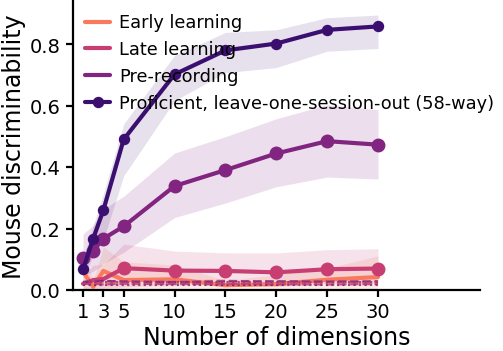

In [45]:
# --- Mouse discriminability across learning timepoints ---
# `labels` and `colors` come from TIMEPOINTS, so they follow USE_TIMEPOINTS automatically.
# Every SIZE in this cell is taken from the active paper_style mode -- no literal point
# sizes or line widths -- so ps.use('paper') in the header cell redraws exactly this
# figure at journal size, and ps.use('poster') at poster size.
ps.reapply()          # rcParams are global and sticky -- re-assert the mode

LW = plt.rcParams['lines.linewidth']
MS = plt.rcParams['lines.markersize']

x_min, x_max = np.min(n_components), np.max(n_components)
fig, ax = ps.figure('single', scale=.75)

for d, name in enumerate(USE_TIMEPOINTS):
    if np.all(np.isnan(scores[d, :])):
        continue

    # Trial data has no dimensionality sweep -> single dot at x = number of trial features
    if d in feature_dims:
        ax.errorbar(feature_dims[d], scores[d, 0],
                    yerr=[[scores[d, 0] - score_ci_low[d, 0]],
                          [score_ci_high[d, 0] - scores[d, 0]]],
                    fmt='o', color=colors[d], label=labels[d])
        continue

    ax.plot(n_components, scores[d, :], color=colors[d], label=labels[d], linestyle='-')

    # Band = 95% CI over held-out mice (not the across-subsample spread)
    ax.fill_between(n_components,
                    score_ci_low[d, :],
                    score_ci_high[d, :],
                    color=colors[d], alpha=0.15, lw=0)

    # Empirical null: LDA fit to shuffled training labels, same colour, dashed.
    # This is the chance level to report -- it absorbs finite-sample bias that the
    # analytic 1/n_classes does not.
    ax.plot(n_components, shuffle_scores[d, :], color=colors[d],
            linestyle='dashed', linewidth=LW * 0.55, alpha=0.9)

    # Mark the sweep points that beat their own shuffled null
    sig = p_perm[d, :] < 0.05
    if np.any(sig):
        ax.plot(np.array(n_components)[sig], scores[d, :][sig], 'o',
                color=colors[d], ms=MS)

# --- PROFICIENT REFERENCE ---------------------------------------------------
# The same baseline LDA, scored on the proficient sessions its balanced subsample
# did not train on. It is the ceiling this sweep never showed: mouse identifiability
# with NO timepoint change involved, only held-out sessions. A timepoint curve well
# below it is losing identity to the change in learning stage, not to the classifier.
# PASS 3 gives ONE proficient curve: leave-one-session-out over every mouse with
# >= MIN_PROF_SESSIONS proficient sessions, independent of the timepoints tested.
# Its chance level is its own (more mice = harder), and is drawn dotted in blue.
if 'prof_loso' in globals() and not np.all(np.isnan(prof_loso)):
    ax.plot(n_components, prof_loso, color=ps.TIMEPOINT['Proficient'], linestyle='-',
            linewidth=LW, marker='o', ms=MS * 0.8,
            label=f'Proficient, leave-one-session-out ({int(prof_loso_n)}-way)')
    ax.fill_between(n_components, prof_loso_ci_low, prof_loso_ci_high,
                    color=ps.TIMEPOINT['Proficient'], alpha=0.12, lw=0)
    ax.hlines(1 / prof_loso_n, x_min, x_max, colors=ps.TIMEPOINT['Proficient'],
              linestyles='dotted', linewidth=LW * 0.5, alpha=0.7)
else:
    print("!! PASS 3 not run -- no proficient reference on the figure")
# ---------------------------------------------------------------------------

# Analytic chance, 1 / (number of mice classified in that dataset). Verified to be
# the correct value: every test session belongs to a mouse the LDA was trained on.
# With a common cohort this is one shared line, since every timepoint scores the same mice.
for d in range(len(USE_TIMEPOINTS)):
    if np.all(np.isnan(scores[d, :])) or np.isnan(n_mice_per_dataset[d]):
        continue
    ax.hlines(1 / n_mice_per_dataset[d], x_min, x_max, colors=colors[d],
              linestyles='dotted', linewidth=LW * 0.5, alpha=0.7)

cohort_note = (f'same {len(cohort)} mice at every timepoint'
               if cohort is not None else 'per-timepoint mice (not comparable)')

# Label only the sweep points that can carry a label at poster type: with ticks at
# every value, 1/2/3/5 run into each other. The unlabelled points are still plotted.
_span = max(n_components) - min(n_components)
_ticks, _last = [], -np.inf
for _n in sorted(n_components):
    if _n - _last >= 0.05 * _span:
        _ticks.append(int(_n)); _last = _n
ax.set_xticks(_ticks or [int(n) for n in n_components])
ax.set_xlim([0, 40])
ax.set_ylim(bottom=0)
ax.set_xlabel('Number of dimensions')
ax.set_ylabel('Mouse discriminability')
ax.legend(fontsize=plt.rcParams['font.size'] * 0.8, loc='upper left')

# WHAT USED TO BE IN THE TITLE is printed instead. A three-line encoding note is
# unreadable at poster type and belongs in the poster's caption; the figure keeps only
# what the panel IS. Set TITLE_NOTE = True to put it back while exploring.
TITLE_NOTE = False
_note = ('solid = accuracy (band: 95% CI over mice), blue = held-out proficient, '
         'dashed = shuffled-label null, dotted = 1/n_mice, '
         f'filled dots = p_perm < 0.05 (p floor {p_floor:.3g}); {cohort_note}')
if TITLE_NOTE:
    ax.set_title(_note, fontsize=plt.rcParams['font.size'] * 0.8, wrap=True)
print(_note)

ps.savefig(fig, 'lda_sweep_timepoints', svg=True)
plt.show()

bars = accuracy at 25 dims (error bars: 95% CI over mice), horizontal ticks = shuffled-label null, stars = p_perm vs that null (floor 0.00498); per-timepoint mice (not comparable)
  Early learning         0.034 [0.004, 0.071]  null 0.026  p 0.1841  (37 mice, analytic chance 0.027)
  Late learning          0.068 [0.021, 0.131]  null 0.018  p 0.00995  (49 mice, analytic chance 0.020)
  Pre-recording          0.485 [0.368, 0.604]  null 0.027  p 0.004975  (37 mice, analytic chance 0.027)
wrote figures/lda_timepoints_bars_25D_poster_14-09-2026.png, figures/lda_timepoints_bars_25D_poster_14-09-2026.svg


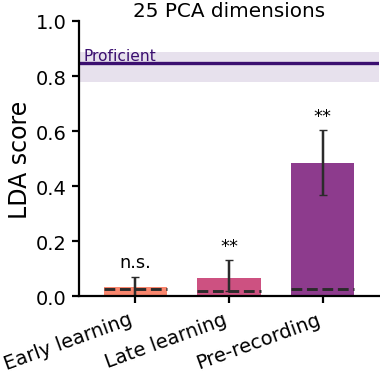

In [56]:
# --- Same result as a BARPLOT, at one fixed dimensionality ---
# The sweep above answers "how does identifiability depend on n_components"; this answers
# "how identifiable is a mouse at each timepoint", which is the comparison the poster makes.
# Reading one column out of the sweep rather than re-running anything, so the two figures
# cannot disagree.
ps.reapply()          # rcParams are global and sticky -- re-assert the mode

N_DIM_BAR = 25       # 25 is where Pre-recording peaks; 30 is already past it (overfitting)
assert N_DIM_BAR in list(n_components), (
    f'{N_DIM_BAR} is not in n_components {list(n_components)} -- add it and re-run PASS 2')
b = list(n_components).index(N_DIM_BAR)

LW = plt.rcParams['lines.linewidth']
shown = [d for d, _ in enumerate(USE_TIMEPOINTS) if not np.isnan(scores[d, b])]

fig, ax = ps.figure('square', scale=.6)
xx = np.arange(len(shown))

for k, d in enumerate(shown):
    ax.bar(k, scores[d, b], width=0.68, color=colors[d], alpha=0.9,
           label=labels[d] if k == 0 else None)
    # error bar = 95% CI over held-out MICE (asymmetric), not the across-subsample spread
    ax.errorbar(k, scores[d, b],
                yerr=[[scores[d, b] - score_ci_low[d, b]],
                      [score_ci_high[d, b] - scores[d, b]]],
                fmt='none', ecolor=ps.STATE_INK, capsize=3, lw=LW * 0.6)
    # the empirical null for THIS timepoint: LDA fit to shuffled training labels. Preferred
    # over analytic 1/n_mice because it absorbs finite-sample bias -- and because the
    # timepoints have different mouse counts, so they do not share one chance level.
    ax.plot([k - 0.34, k + 0.34], [shuffle_scores[d, b]] * 2, color=ps.STATE_INK,
            lw=LW * 0.7, zorder=3, ls='--')
    # significance against that null. NOTE the permutation floor: with n_perm draws p can
    # never fall below 1/(n_perm+1), so '***' (p < 1e-3) is unreachable at n_perm = 200.
    ax.text(k, score_ci_high[d, b] + 0.02, ps.stars(p_perm[d, b]),
            ha='center', va='bottom', fontsize=plt.rcParams['font.size'] * 0.8)

# --- PROFICIENT CEILING -----------------------------------------------------
# Leave-one-session-out over proficient sessions (PASS 3): identifiability with no
# timepoint change involved. A bar well below it is losing identity to the learning stage,
# not to the classifier.
if 'prof_loso' in globals() and not np.isnan(prof_loso[b]):
    ax.axhline(prof_loso[b], color=ps.TIMEPOINT['Proficient'], ls='-', lw=LW * 0.8)
    ax.axhspan(prof_loso_ci_low[b], prof_loso_ci_high[b], 
               color=ps.TIMEPOINT['Proficient'], alpha=0.12, lw=0)
    # ax.text(-0.55, prof_loso[b], f'Proficient, leave-one-session-out '
    #         f'({int(prof_loso_n)}-way)', va='bottom', ha='left',
    #         color=ps.TIMEPOINT['Proficient'],
    #         fontsize=plt.rcParams['font.size'] * 0.7)
    ax.text(-0.55, prof_loso[b], f'Proficient', va='bottom', ha='left',
            color=ps.TIMEPOINT['Proficient'],
            fontsize=plt.rcParams['font.size'] * 0.7)

ax.set_xticks(xx)
# rotated: the full timepoint names overlap at poster type with only three bars
ax.set_xticklabels([labels[d] for d in shown], rotation=20, ha='right')
ax.set_ylabel('LDA score')
ax.set_xlim(-0.6, len(shown) - 0.4)
_top = max(np.nanmax(score_ci_high[shown, b]),
           prof_loso[b] if 'prof_loso' in globals() and not np.isnan(prof_loso[b]) else 0)
ax.set_ylim(0, _top * 1.18)          # room for the stars and the ceiling label
ax.set_title(f'{N_DIM_BAR} PCA dimensions', fontsize=plt.rcParams['font.size'] * 0.9)

_bar_note = (f'bars = accuracy at {N_DIM_BAR} dims (error bars: 95% CI over mice), '
             f'horizontal ticks = shuffled-label null, stars = p_perm vs that null '
             f'(floor {p_floor:.3g}); {cohort_note}')
print(_bar_note)
for d in shown:
    print(f'  {labels[d]:<22s} {scores[d, b]:.3f} '
          f'[{score_ci_low[d, b]:.3f}, {score_ci_high[d, b]:.3f}]  '
          f'null {shuffle_scores[d, b]:.3f}  p {p_perm[d, b]:.4g}  '
          f'({int(n_mice_per_dataset[d])} mice, analytic chance {1 / n_mice_per_dataset[d]:.3f})')

fig.tight_layout()
ps.savefig(fig, f'lda_timepoints_bars_{N_DIM_BAR}D', svg=True)
plt.show()


In [47]:
# --- Numbers behind the figure ---
if cohort is not None:
    print(f"Common cohort ({len(cohort)} mice present at all of {USE_TIMEPOINTS}):")
    print("  " + ", ".join(cohort))
else:
    print("Per-timepoint mice -- scores below are NOT comparable across timepoints")

print("\nPROFICIENT REFERENCE -- held-out proficient sessions, same baseline LDA")
for d, name in enumerate(USE_TIMEPOINTS):
    if np.all(np.isnan(prof_scores[d, :])):
        continue
    print(f"  cohort of {name}: {int(prof_n_mice[d])} mice had spare proficient sessions")
    print(f"  {'nPC':>4s} {'acc':>6s} {'95% CI over mice':>18s}")
    for b, npc in enumerate(n_components):
        if np.isnan(prof_scores[d, b]):
            continue
        print(f"  {npc:4d} {prof_scores[d, b]:6.3f} "
              f"[{prof_ci_low[d, b]:6.3f},{prof_ci_high[d, b]:6.3f}]")
    if cohort is not None:
        break
also, why is performance different from 
for d, name in enumerate(USE_TIMEPOINTS):
    if np.all(np.isnan(scores[d, :])):
        continue
    print(f"\n{labels[d]}  ({int(n_mice_per_dataset[d])} mice, "
          f"analytic chance {1/n_mice_per_dataset[d]:.3f})")
    print(f"  (permutation p-value floor: {p_floor:.4g})")
    print(f"  {'nPC':>4s} {'acc':>6s} {'95% CI over mice':>18s} {'null':>6s} {'p_perm':>7s}")
    for b, npc in enumerate(n_components):
        if np.isnan(scores[d, b]):
            continue
        print(f"  {npc:4d} {scores[d, b]:6.3f} "
              f"[{score_ci_low[d, b]:6.3f},{score_ci_high[d, b]:6.3f}] "
              f"{shuffle_scores[d, b]:6.3f} {p_perm[d, b]:7.3f}")

SyntaxError: invalid syntax (3589369688.py, line 21)